# Question 1: Using deep transfer learning for image-based plant disease identification

by AhmadReza Nopoush

610301194

## 1. Dataset Prepration

In [11]:
import pathlib
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub
import random

In [12]:
# Set random seed for reproducibility
np.random.seed(46)
random.seed(46)

In [15]:
from numpy.random import seed
# Download dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("anshulm257/rice-disease-dataset")
print(f"Dataset downloaded to: {path}")

# The dataset contains 6 classes:
# "Bacterial Leaf Blight", "Brown Spot", "Healthy Rice Leaf", "Leaf Blast", "Leaf scald", and "Sheath Blight"

# The actual disease classes are inside the "Rice_Leaf_AUG" directory
rice_leaf_dir = pathlib.Path(path) / "Rice_Leaf_AUG"

# Get all available disease classes
available_classes = [d.name for d in rice_leaf_dir.iterdir() if d.is_dir()]
print("\nAvailable disease classes:")
for i, cls in enumerate(available_classes):
    print(f"{i+1}. {cls}")

# Identify healthy class
healthy_class = "Healthy Rice Leaf"

# Get disease classes (excluding healthy)
disease_classes = [cls for cls in available_classes if cls != healthy_class]

# Randomly select 3 disease classes
selected_disease_classes = np.random.choice(disease_classes, size=3, replace=False).tolist()

# Combine healthy class with selected disease classes
selected_classes = [healthy_class] + selected_disease_classes
print(f"\nUsing 4 classes: {selected_classes}")

Using Colab cache for faster access to the 'rice-disease-dataset' dataset.
Dataset downloaded to: /kaggle/input/rice-disease-dataset

Available disease classes:
1. Leaf scald
2. Sheath Blight
3. Healthy Rice Leaf
4. Leaf Blast
5. Brown Spot
6. Bacterial Leaf Blight

Using 4 classes: ['Healthy Rice Leaf', 'Sheath Blight', 'Bacterial Leaf Blight', 'Leaf Blast']



Organizing dataset...


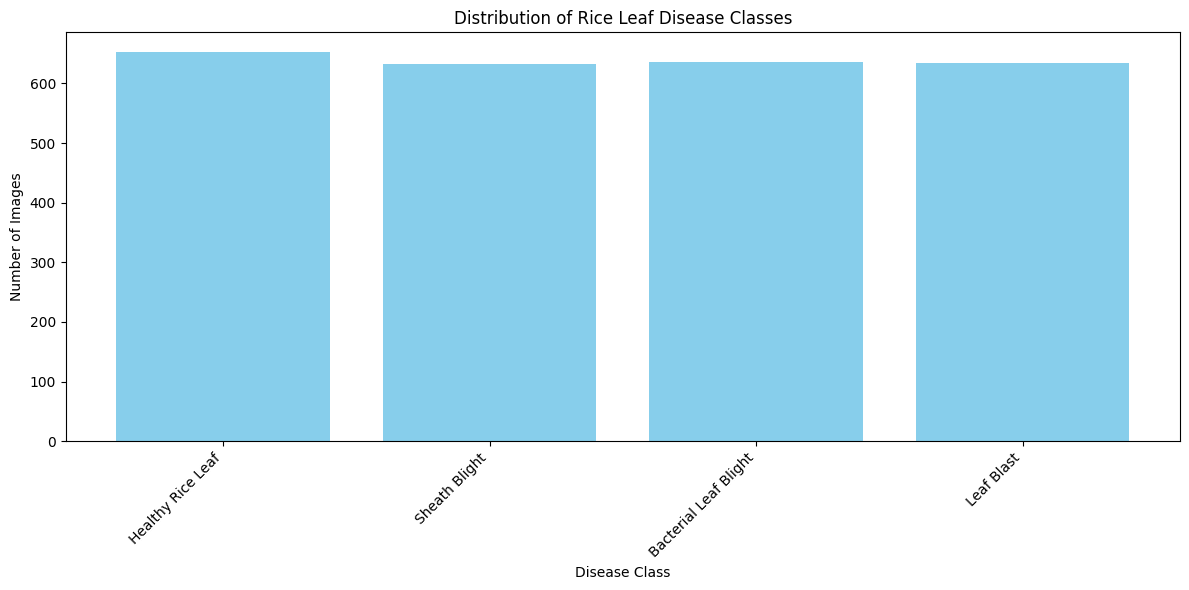


Dataset Split Verification:
Healthy Rice Leaf: Train=457 (70.0%), Val=98 (15.0%), Test=98 (15.0%)
Sheath Blight: Train=442 (69.9%), Val=95 (15.0%), Test=95 (15.0%)
Bacterial Leaf Blight: Train=445 (70.0%), Val=95 (14.9%), Test=96 (15.1%)
Leaf Blast: Train=443 (69.9%), Val=95 (15.0%), Test=96 (15.1%)


In [16]:
# Create directories for organized dataset
base_dir = pathlib.Path('rice_dataset')
train_dir = base_dir / 'train'
val_dir = base_dir / 'validation'
test_dir = base_dir / 'test'

# Create all directories
for dir_path in [train_dir, val_dir, test_dir]:
    dir_path.mkdir(exist_ok=True, parents=True)
    for cls in selected_classes:
        (dir_path / cls).mkdir(exist_ok=True)

# Copy selected classes to new structure
print("\nOrganizing dataset...")
class_counts = {}

for cls in selected_classes:
    src_dir = rice_leaf_dir / cls
    files = list(src_dir.glob('*'))  # Get all files in the directory

    # Skip if no files found
    if not files:
        print(f"Warning: No files found for class '{cls}'. Skipping this class.")
        continue

    class_counts[cls] = len(files)

    # Split files into train (70%), validation (15%), and test (15%)
    # First split: 70% train, 30% temp
    train_files, temp_files = train_test_split(files, test_size=0.3, random_state=42)
    # Second split: 50% of temp for validation, 50% for test (15% each of total)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    # Copy files to respective directories
    for file in train_files:
        shutil.copy(str(file), str(train_dir / cls / file.name))
    for file in val_files:
        shutil.copy(str(file), str(val_dir / cls / file.name))
    for file in test_files:
        shutil.copy(str(file), str(test_dir / cls / file.name))

# Check if we have any classes with data
if not class_counts:
    print("Error: No valid classes found with data. Exiting.")
    exit()

# Plot class distribution histogram
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title('Distribution of Rice Leaf Disease Classes')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# Verify splits
print("\nDataset Split Verification:")
for cls in class_counts.keys():
    train_count = len(list((train_dir / cls).glob('*')))
    val_count = len(list((val_dir / cls).glob('*')))
    test_count = len(list((test_dir / cls).glob('*')))
    total = train_count + val_count + test_count
    print(f"{cls}: Train={train_count} ({train_count/total:.1%}), "
          f"Val={val_count} ({val_count/total:.1%}), Test={test_count} ({test_count/total:.1%})")

## 2. Data Preprocessing

In [17]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import random
import torchvision.transforms as transforms

In [18]:
# For training data with augmentation
train_transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
    transforms.RandomVerticalFlip(p=0.5),  # Random vertical flip
    transforms.RandomRotation(15),  # Random rotation up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color variations
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
    transforms.ToTensor(),  # Convert to tensor
])

# For validation and test data without augmentation
test_transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
])

# Create datasets
train_alexnet = datasets.ImageFolder(root='rice_dataset/train', transform=train_transform_alexnet)
val_alexnet   = datasets.ImageFolder(root='rice_dataset/validation', transform=test_transform_alexnet)
test_alexnet  = datasets.ImageFolder(root='rice_dataset/test', transform=test_transform_alexnet)

# Create data loaders
BATCH_SIZE = 32
train_loader_alexnet = DataLoader(train_alexnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_alexnet = DataLoader(val_alexnet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_alextnet = DataLoader(test_alexnet, batch_size=BATCH_SIZE, shuffle=False)

# Print class names (important)
class_names = train_alexnet.classes
print("\nClass labels:", class_names)
print("\nDataLoaders created successfully!")
print("Train size:", len(train_alexnet))
print("Validation size:", len(val_alexnet))
print("Test size:", len(test_alexnet))


Class labels: ['Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight']

DataLoaders created successfully!
Train size: 1787
Validation size: 383
Test size: 385


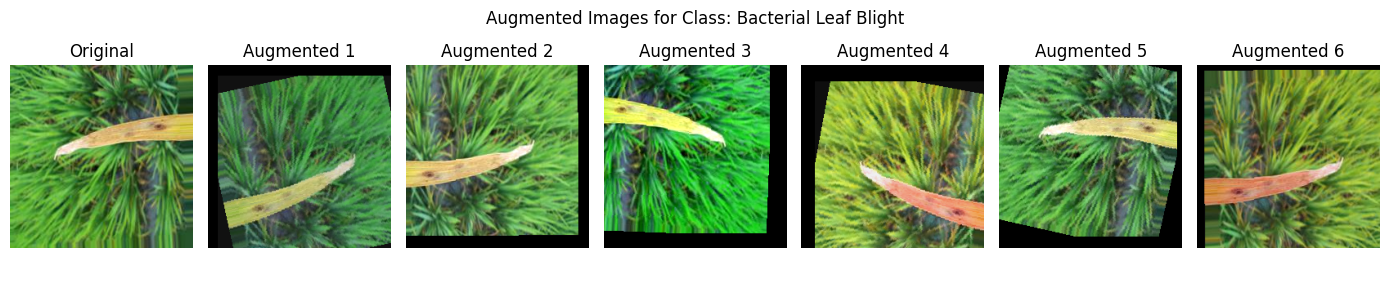

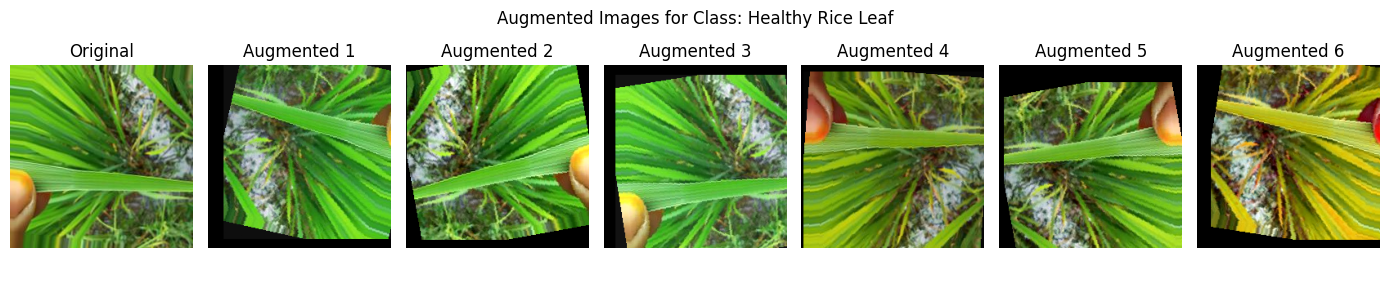

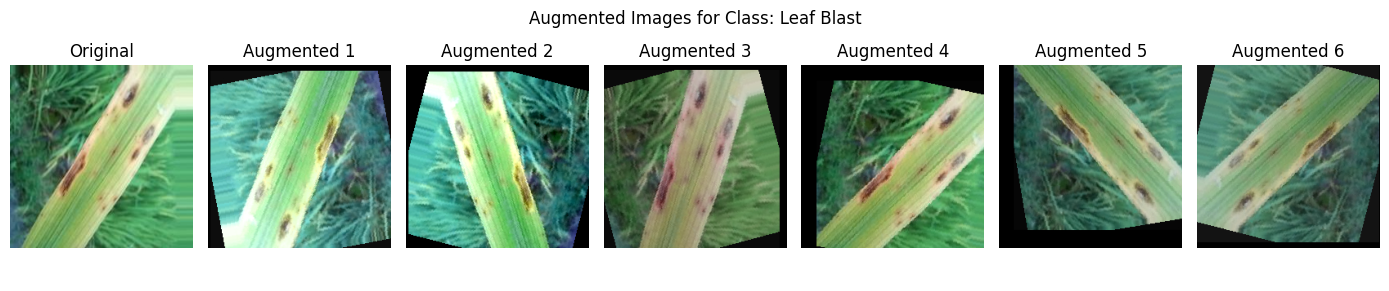

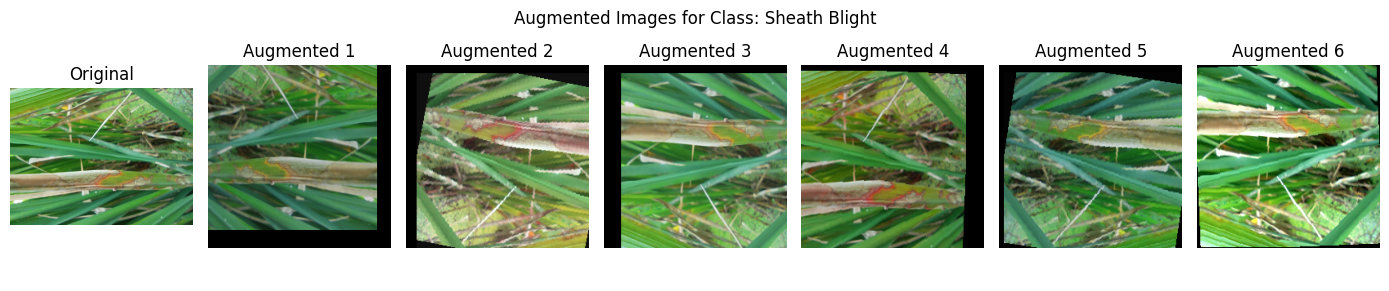

In [19]:
# Function to display augmented images
def show_augmented_images(dataset, class_name, num_images=5):

    # Directory for the class (dataset.root/class_name)
    class_dir = pathlib.Path(dataset.root) / class_name

    # Get all image paths
    image_paths = list(class_dir.glob('*'))

    if len(image_paths) == 0:
        print(f"⚠ No images found for class: {class_name}")
        return

    # Randomly select one image
    img_path = random.choice(image_paths)

    # Load image (PIL)
    img_pil = torchvision.datasets.folder.default_loader(str(img_path))

    # Start plot
    plt.figure(figsize=(14, 3))
    plt.title(f"Augmented Images for Class: {class_name}")
    plt.axis('off')

    # Show Original image
    plt.subplot(1, num_images + 1, 1)
    plt.imshow(img_pil)
    plt.title("Original")
    plt.axis("off")

    # Show Augmented images
    for i in range(num_images):
        augmented_img = train_transform_alexnet(img_pil)
        augmented_img = augmented_img.permute(1, 2, 0).numpy()  # CHW → HWC

        plt.subplot(1, num_images + 1, i + 2)
        plt.imshow(augmented_img)
        plt.title(f"Augmented {i+1}")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    plt.show()

# Display augmented images for classes
for cls in class_names:
    show_augmented_images(train_alexnet, cls, num_images=6)

## 3.1. AlexNet Architecture

In [20]:
import torch.nn as nn
import torch.optim as optim
import time
from torchsummary import summary

In [21]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 96 filters, 11x11, stride 4, pad 2
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2: 256 filters, 5x5, pad 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3: 384 filters
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 384 filters
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 256 filters
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


## Training Function

we use `nn.CrossEntropyLoss()` as loss and `torch.optim.SGD()` as optimizer.

In [22]:
# Function for training the model (adapted for classification)
def fit(model, train_loader, optimizer, criterion, device):
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0

    for inputs, targets in train_loader:
        counter += 1
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)   # Calculate outputs
        loss = criterion(outputs, targets)     # Calculate Loss

        # Calculate accuracy
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == targets).sum().item()

        optimizer.zero_grad()   # Reset gradients
        loss.backward()   # Backpropagate the loss
        optimizer.step()   # Update the weights

        train_running_loss += loss.item()

    train_loss = train_running_loss / counter  # Average epoch loss
    train_accuracy = 100. * train_running_correct / len(train_loader.dataset)
    return train_loss, train_accuracy

# Function for evaluating the validation data (adapted for classification)
def validation(model, data_loader, criterion, device):
    model.eval()    # Evaluation mode (do not allow weight updates)
    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0

    with torch.no_grad():  # No need to calculate gradients during validation
        for inputs, targets in data_loader:
            counter += 1
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Calculate accuracy
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == targets).sum().item()

            val_running_loss += loss.item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / len(data_loader.dataset)
    return val_loss, val_accuracy

# The main method for training the model through epochs
def train(model, hparams, train_loader, val_loader, device):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=hparams['lr'],
                                momentum=hparams['momentum'], weight_decay=hparams['weight_decay'])

    history = []

    # Loop over epochs
    for epoch in range(hparams['epochs']):
        print(f"Epoch {epoch+1} of {hparams['epochs']}")
        start = time.time()

        train_epoch_loss, train_epoch_accuracy = fit(model, train_loader, optimizer, criterion, device)
        val_epoch_loss, val_epoch_accuracy = validation(model, val_loader, criterion, device)

        end = time.time()

        history.append({
            'epoch': epoch+1,
            'train_loss': train_epoch_loss,
            'train_accuracy': train_epoch_accuracy,
            'val_loss': val_epoch_loss,
            'val_accuracy': val_epoch_accuracy,
            'trainin_time': end - start
        })

        print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}%")
        print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}%")

    return model, history

## 3.2. Training AlexNet and Results

#### building AlexNet model

In [23]:
# Number of classes (already defined from your dataset)
num_classes = len(train_alexnet.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {train_alexnet.classes}")

# Initialize Alex-Net model
AN_model = AlexNet(num_classes=num_classes)

# Move model to CPU for summary
AN_cpu = AlexNet(num_classes=num_classes)
AN_cpu = AN_cpu.to("cpu")

# Print model summary
print("\nAlexNet Model Summary:")
summary(AN_cpu, input_size=(3, 224, 224), device="cpu")

# Move main model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
AN_model = AN_model.to(device)
print(f"\nModel moved to {device}")


Number of classes: 4
Classes: ['Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight']

AlexNet Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 

#### Training

In [24]:
# Hyperparameters
hparams = {
    'epochs': 30,
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 5e-4
}

# Train the model
print("\nStarting training...")
model, history = train(AN_model, hparams, train_loader_alexnet, val_loader_alexnet, device)


Starting training...
Epoch 1 of 30
Train Loss: 1.3869, Train Acc: 25.46%
Val Loss: 1.3860, Val Acc: 25.59%
Epoch 2 of 30
Train Loss: 1.3871, Train Acc: 23.95%
Val Loss: 1.3856, Val Acc: 25.59%
Epoch 3 of 30
Train Loss: 1.3863, Train Acc: 25.57%
Val Loss: 1.3844, Val Acc: 36.55%
Epoch 4 of 30
Train Loss: 1.3842, Train Acc: 26.41%
Val Loss: 1.3776, Val Acc: 29.77%
Epoch 5 of 30
Train Loss: 1.3696, Train Acc: 33.63%
Val Loss: 1.4025, Val Acc: 25.59%
Epoch 6 of 30
Train Loss: 1.3881, Train Acc: 24.57%
Val Loss: 1.3823, Val Acc: 40.21%
Epoch 7 of 30
Train Loss: 1.3578, Train Acc: 32.90%
Val Loss: 1.2592, Val Acc: 40.47%
Epoch 8 of 30
Train Loss: 1.2802, Train Acc: 35.48%
Val Loss: 1.3686, Val Acc: 24.80%
Epoch 9 of 30
Train Loss: 1.2401, Train Acc: 41.86%
Val Loss: 1.1232, Val Acc: 43.86%
Epoch 10 of 30
Train Loss: 1.1212, Train Acc: 48.74%
Val Loss: 0.9972, Val Acc: 61.10%
Epoch 11 of 30
Train Loss: 1.0887, Train Acc: 50.81%
Val Loss: 1.0938, Val Acc: 43.86%
Epoch 12 of 30
Train Loss: 0.9

#### Loss and Accuracy Plots

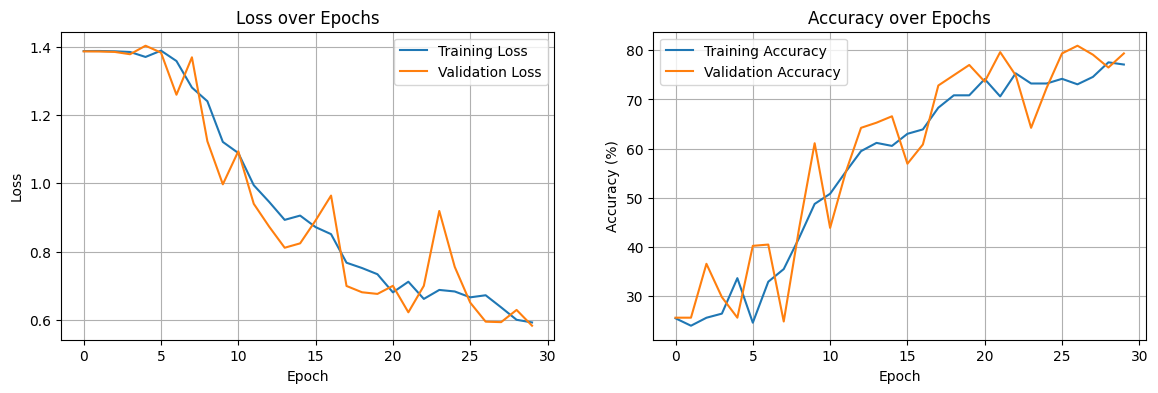

In [25]:
train_loss_alexnet = [h['train_loss'] for h in history]
val_loss_alexnet   = [h['val_loss'] for h in history]
train_acc_alexnet  = [h['train_accuracy'] for h in history]
val_acc_alexnet    = [h['val_accuracy'] for h in history]
train_time_alexnet = [h['trainin_time'] for h in history]

# Plot training history
plt.figure(figsize=(14, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_alexnet, label='Training Loss')
plt.plot(val_loss_alexnet, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_alexnet, label='Training Accuracy')
plt.plot(val_acc_alexnet, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

#### loss and accuracy on test data




In [27]:
criterion = nn.CrossEntropyLoss()
test_loss_alexnet, test_accuracy_alexnet = validation(AN_model, test_loader_alextnet, criterion, device)
print(f"Test Loss: {test_loss_alexnet:.4f}")
print(f"Test Accuracy: {test_accuracy_alexnet:.2f}%")

Test Loss: 0.6097
Test Accuracy: 74.55%


#### Confusion Matrix

In [28]:
# Function to get predictions and true labels (extended version of validate)
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

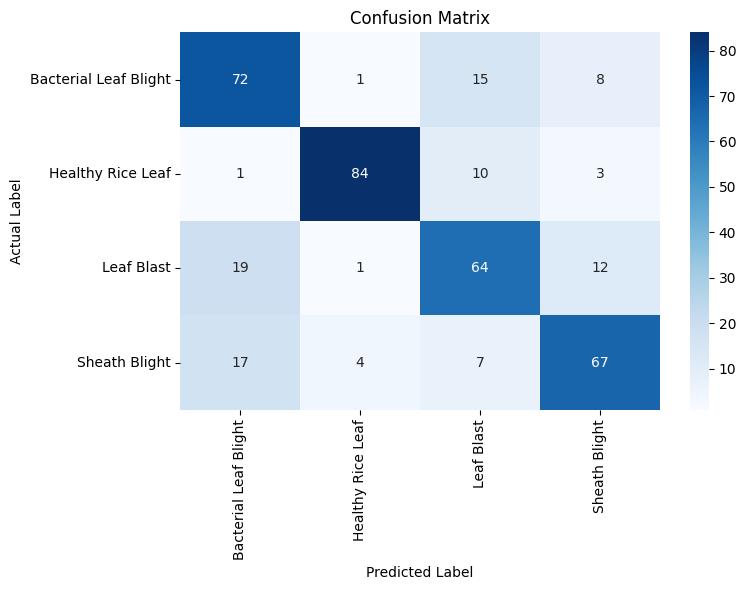

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import pandas as pd
import seaborn as sns

# Get predictions and true labels for test set
test_preds_alexnet, test_labels_alexnet = get_predictions(model, test_loader_alextnet, device)

# Calculate confusion matrix
cm_alexnet = confusion_matrix(test_labels_alexnet, test_preds_alexnet)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_alexnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

#### Metrics

function to calculate metrics from confusion matrix

In [36]:
def evaluate_metrics(cm, class_names):
    """
    Computes:
      - Accuracy
      - Sensitivity (Recall)
      - Specificity
      - Precision
      - F1 Score
    for each class and the average row.

    Returns:
      metrics_df  → Full detailed metrics
      table_df    → Reduced table (Accuracy, Sensitivity, Specificity)
    """

    num_classes = len(class_names)
    metrics = []

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = (2 * precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

        metrics.append({
            "Class": class_names[i],
            "Accuracy": accuracy * 100,
            "Sensitivity": sensitivity * 100,
            "Specificity": specificity * 100,
            "Precision": precision * 100,
            "F1 Score": f1 * 100,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    # ----- Averages -----
    metrics_df = pd.DataFrame(metrics)

    avg_row = {
        "Class": "Average",
        "Accuracy": metrics_df["Accuracy"].mean(),
        "Sensitivity": metrics_df["Sensitivity"].mean(),
        "Specificity": metrics_df["Specificity"].mean(),
        "Precision": metrics_df["Precision"].mean(),
        "F1 Score": metrics_df["F1 Score"].mean(),
        "TP": "",
        "FP": "",
        "FN": "",
        "TN": ""
    }

    metrics_df = pd.concat([metrics_df, pd.DataFrame([avg_row])], ignore_index=True)

    # --- Table 4 format (Accuracy, Sensitivity, Specificity) ---
    table_df = metrics_df[["Class", "Accuracy", "Sensitivity", "Specificity"]].copy()
    table_df = table_df.round(2)

    return metrics_df, table_df


applying on `cm_alexnet`

In [37]:
metrics_alexnet, table_alexnet = evaluate_metrics(cm_alexnet, class_names)

print("\n=== Table 4 Style Report ===")
print(table_alexnet.to_string(index=False))

print("\n=== Detailed Metrics ===")
print(metrics_alexnet.round(2))



=== Table 4 Style Report ===
                Class  Accuracy  Sensitivity  Specificity
Bacterial Leaf Blight     84.16        75.00        87.20
    Healthy Rice Leaf     94.81        85.71        97.91
           Leaf Blast     83.38        66.67        88.93
        Sheath Blight     86.75        70.53        92.07
              Average     87.27        74.48        91.53

=== Detailed Metrics ===
                   Class  Accuracy  Sensitivity  Specificity  Precision  \
0  Bacterial Leaf Blight     84.16        75.00        87.20      66.06   
1      Healthy Rice Leaf     94.81        85.71        97.91      93.33   
2             Leaf Blast     83.38        66.67        88.93      66.67   
3          Sheath Blight     86.75        70.53        92.07      74.44   
4                Average     87.27        74.48        91.53      75.12   

   F1 Score  TP  FP  FN   TN  
0     70.24  72  37  24  252  
1     89.36  84   6  14  281  
2     66.67  64  32  32  257  
3     72.43  67  23  

## 4.0. Redefining Dataloaders

In [38]:
# For training data with augmentation
train_transform_incvggn = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
    transforms.RandomVerticalFlip(p=0.5),  # Random vertical flip
    transforms.RandomRotation(15),  # Random rotation up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color variations
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# For validation and test data without augmentation
test_transform_incvggn = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_incvggn = datasets.ImageFolder(root='rice_dataset/train', transform=train_transform_incvggn)
val_incvggn   = datasets.ImageFolder(root='rice_dataset/validation', transform=test_transform_incvggn)
test_incvggn  = datasets.ImageFolder(root='rice_dataset/test', transform=test_transform_incvggn)

# Create data loaders
BATCH_SIZE = 32
train_loader_incvggn = DataLoader(train_incvggn, batch_size=BATCH_SIZE, shuffle=True)
val_loader_incvggn = DataLoader(val_incvggn, batch_size=BATCH_SIZE, shuffle=False)
test_loader_incvggn = DataLoader(test_incvggn, batch_size=BATCH_SIZE, shuffle=False)

# Print class names (important)
class_names = train_incvggn.classes
print("\nClass labels:", class_names)
print("\nDataLoaders created successfully!")
print("Train size:", len(train_incvggn))
print("Validation size:", len(val_incvggn))
print("Test size:", len(test_incvggn))


Class labels: ['Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight']

DataLoaders created successfully!
Train size: 1787
Validation size: 383
Test size: 385


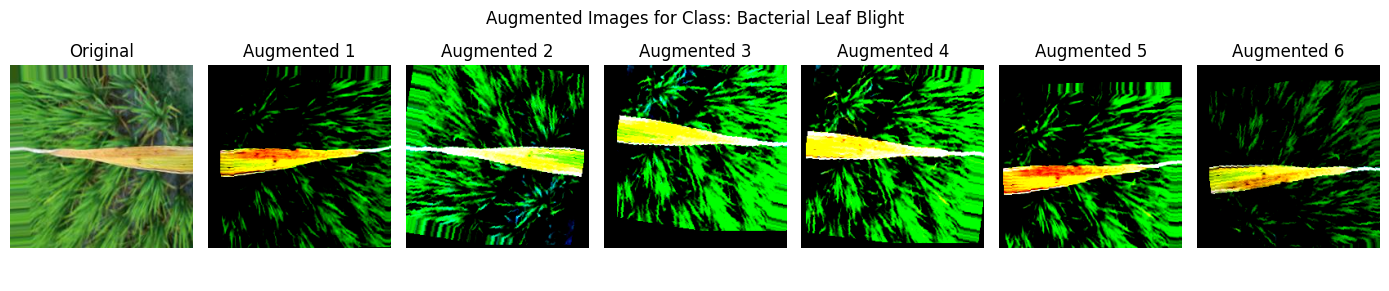

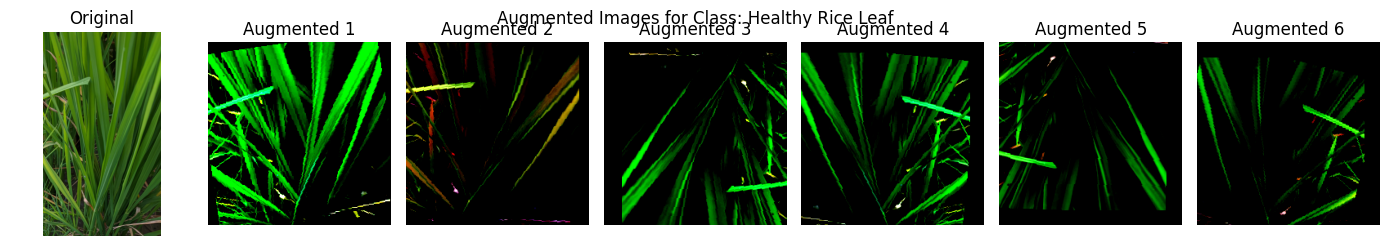

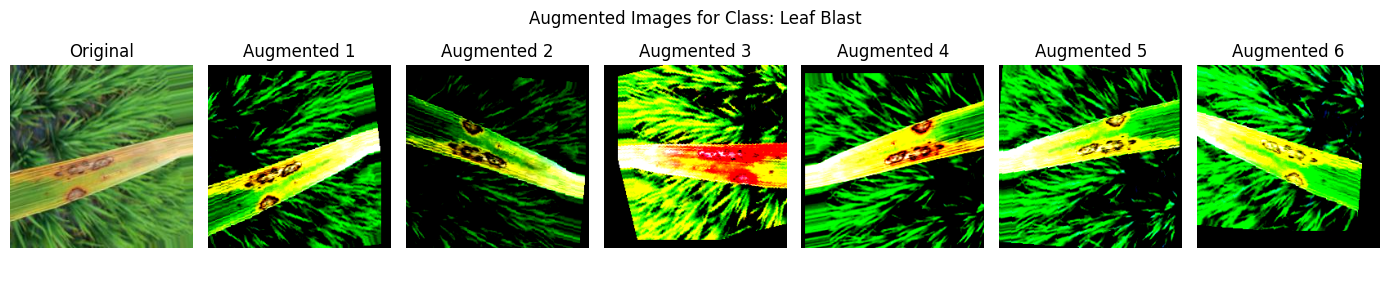

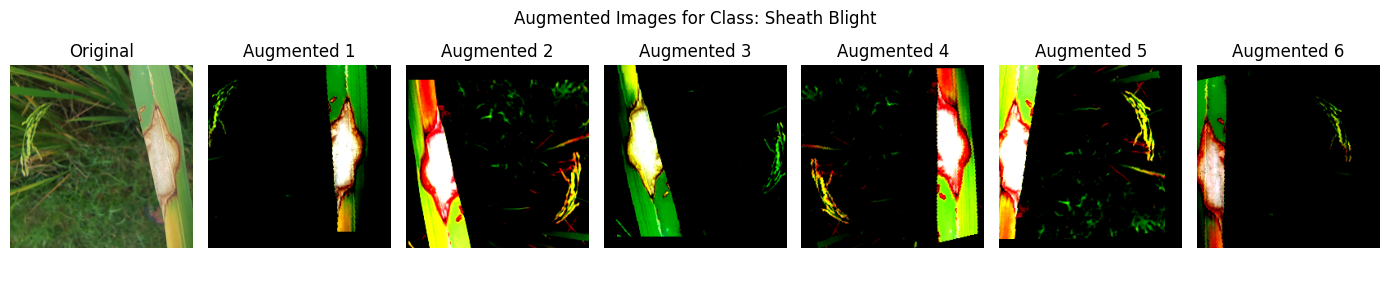

In [43]:
# Function to display augmented images
def show_augmented_images(dataset, class_name, num_images=5):

    # Directory for the class (dataset.root/class_name)
    class_dir = pathlib.Path(dataset.root) / class_name

    # Get all image paths
    image_paths = list(class_dir.glob('*'))

    if len(image_paths) == 0:
        print(f"⚠ No images found for class: {class_name}")
        return

    # Randomly select one image
    img_path = random.choice(image_paths)

    # Load image (PIL)
    img_pil = torchvision.datasets.folder.default_loader(str(img_path))

    # Start plot
    plt.figure(figsize=(14, 3))
    plt.title(f"Augmented Images for Class: {class_name}")
    plt.axis('off')

    # Show Original image
    plt.subplot(1, num_images + 1, 1)
    plt.imshow(img_pil)
    plt.title("Original")
    plt.axis("off")

    # Show Augmented images
    for i in range(num_images):
        augmented_img = train_transform_incvggn(img_pil)
        augmented_img = augmented_img.permute(1, 2, 0).numpy()  # CHW → HWC

        plt.subplot(1, num_images + 1, i + 2)
        plt.imshow(augmented_img)
        plt.title(f"Augmented {i+1}")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    plt.show()

# Display augmented images for classes
for cls in class_names:
    show_augmented_images(train_incvggn, cls, num_images=6)

## 4.1. INC-VGGN Model Architecture

#### building INC-VGGN model

In [44]:
from torchvision import transforms, models

# Swish
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# Inception Module (256 output)
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        b1 = out_channels // 4          # 64
        b2 = out_channels // 4          # 64
        b3 = out_channels - (b1 + b2)   # 128

        # Branch 1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, b1, kernel_size=1),
            nn.BatchNorm2d(b1),
            Swish()
        )

        # Branch 2
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, b2, kernel_size=1),
            nn.BatchNorm2d(b2),
            Swish(),
            nn.Conv2d(b2, b2, kernel_size=3, padding=1),
            nn.BatchNorm2d(b2),
            Swish(),
            nn.Conv2d(b2, b2, kernel_size=3, padding=1),
            nn.BatchNorm2d(b2),
            Swish()
        )

        # Branch 3
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, b3, kernel_size=1),
            nn.BatchNorm2d(b3),
            Swish(),
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(b3, b3, kernel_size=1),
            nn.BatchNorm2d(b3),
            Swish()
        )

    def forward(self, x):
        return torch.cat([self.branch1(x),
                          self.branch2(x),
                          self.branch3(x)], dim=1)


# INC-VGGN Using VGG19 Backbone (Frozen)
class INC_VGGN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Load pretrained VGG19
        vgg19 = models.vgg19(pretrained=True)

        for p in vgg19.parameters():
          p.requires_grad = False

        # Slice Conv1_1 → Pool3 = indices 0..18
        self.vgg_front = nn.Sequential(*list(vgg19.features.children())[:19])
        # Output: 256 channels, 14×14

        # Paper’s custom Conv-BN-Swish (256 → 512)
        self.conv_bn = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            Swish()
        )

        # Two Inception modules (each → 256)
        self.inception1 = InceptionModule(512, 256)
        self.inception2 = InceptionModule(256, 256)

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.vgg_front(x)      # VGG19 Conv1→Pool3
        x = self.conv_bn(x)        # 256→512
        x = self.inception1(x)     # 512→256
        x = self.inception2(x)     # 256→256
        x = self.global_pool(x)    # 1×1×256
        x = torch.flatten(x, 1)
        return self.classifier(x)


#### Initializing INC-VGGN

In [45]:
# Number of classes (already defined from your dataset)
num_classes = len(train_incvggn.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {train_incvggn.classes}")

# Initialize INC-VGGN model
IV_model = INC_VGGN(num_classes=num_classes)

# Move model to CPU for summary
model_incvggn = INC_VGGN(num_classes=num_classes)
model_incvggn = model_incvggn.to("cpu")

# Print model summary
print("\nINC-VGGN Model Summary:")
summary(model_incvggn, input_size=(3, 224, 224), device="cpu")

# Move main model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
IV_model = IV_model.to(device)
print(f"\nModel moved to {device}")

Number of classes: 4
Classes: ['Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 66.0MB/s]



INC-VGGN Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             R

## 4.2. Training INC-VGGN and Results

#### Training

In [46]:
# Hyperparameters
hparams = {
    'epochs': 30,
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 5e-4
}

# Train the model
print("\nStarting training...")
IV_model, history_incvggn = train(IV_model, hparams, train_loader_incvggn, val_loader_incvggn, device)


Starting training...
Epoch 1 of 30
Train Loss: 0.9609, Train Acc: 57.92%
Val Loss: 1.2363, Val Acc: 53.00%
Epoch 2 of 30
Train Loss: 0.5511, Train Acc: 78.68%
Val Loss: 0.5415, Val Acc: 83.03%
Epoch 3 of 30
Train Loss: 0.4434, Train Acc: 82.71%
Val Loss: 0.6297, Val Acc: 76.50%
Epoch 4 of 30
Train Loss: 0.3931, Train Acc: 85.51%
Val Loss: 0.5198, Val Acc: 82.51%
Epoch 5 of 30
Train Loss: 0.3460, Train Acc: 87.13%
Val Loss: 0.3459, Val Acc: 88.77%
Epoch 6 of 30
Train Loss: 0.3078, Train Acc: 87.97%
Val Loss: 0.4358, Val Acc: 84.60%
Epoch 7 of 30
Train Loss: 0.2938, Train Acc: 89.65%
Val Loss: 0.4724, Val Acc: 82.77%
Epoch 8 of 30
Train Loss: 0.2371, Train Acc: 91.05%
Val Loss: 0.2873, Val Acc: 90.08%
Epoch 9 of 30
Train Loss: 0.2215, Train Acc: 93.12%
Val Loss: 0.3327, Val Acc: 89.56%
Epoch 10 of 30
Train Loss: 0.2146, Train Acc: 91.55%
Val Loss: 0.3479, Val Acc: 90.34%
Epoch 11 of 30
Train Loss: 0.2116, Train Acc: 92.17%
Val Loss: 0.4310, Val Acc: 81.98%
Epoch 12 of 30
Train Loss: 0.1

#### Loss and Accuracy Plots

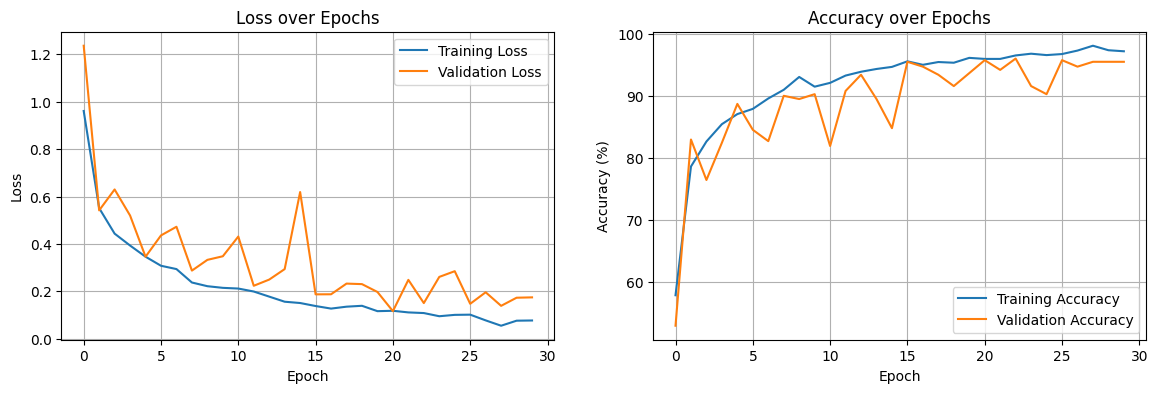

In [47]:
train_loss_incvggn = [h['train_loss'] for h in history_incvggn]
val_loss_incvggn  = [h['val_loss'] for h in history_incvggn]
train_acc_incvggn  = [h['train_accuracy'] for h in history_incvggn]
val_acc_incvggn    = [h['val_accuracy'] for h in history_incvggn]
train_time_incvggn = [h['trainin_time'] for h in history_incvggn]

# Plot training history
plt.figure(figsize=(14, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_incvggn, label='Training Loss')
plt.plot(val_loss_incvggn, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_incvggn, label='Training Accuracy')
plt.plot(val_acc_incvggn, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

#### loss and accuracy on test data

In [48]:
criterion = nn.CrossEntropyLoss()
test_loss_incvggn, test_accuracy_incvggn = validation(IV_model, test_loader_incvggn, criterion, device)
print(f"Test Loss: {test_loss_incvggn:.4f}")
print(f"Test Accuracy: {test_accuracy_incvggn:.2f}%")

Test Loss: 0.2071
Test Accuracy: 94.03%


#### Confusion Matrix

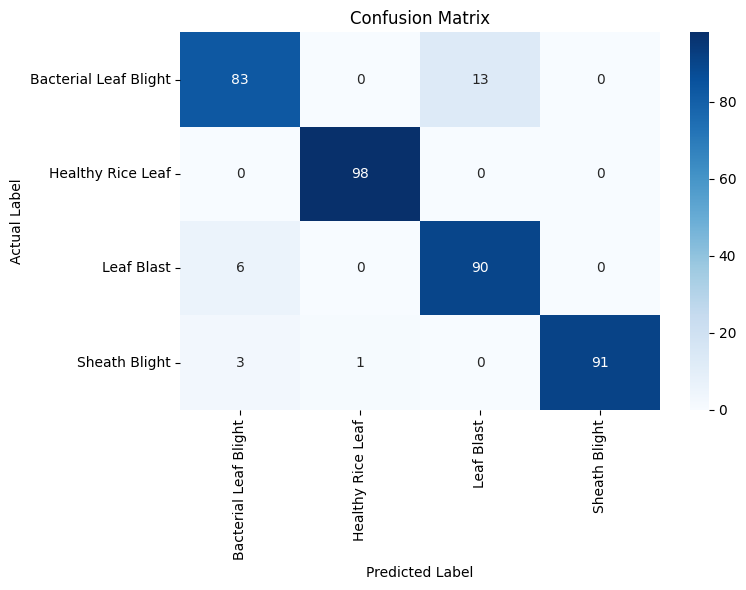

In [49]:
# Get predictions and true labels for test set
test_preds_incvggn, test_labels_incvggn = get_predictions(IV_model, test_loader_incvggn, device)

# Calculate confusion matrix
cm_incvggn = confusion_matrix(test_labels_incvggn, test_preds_incvggn)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_incvggn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

#### Metrics

In [50]:
metrics_incvggn, table_incvggn = evaluate_metrics(cm_incvggn, class_names)

print("\n=== Table 4 Style Report ===")
print(table_incvggn.to_string(index=False))

print("\n=== Detailed Metrics ===")
print(metrics_incvggn.round(2))


=== Table 4 Style Report ===
                Class  Accuracy  Sensitivity  Specificity
Bacterial Leaf Blight     94.29        86.46        96.89
    Healthy Rice Leaf     99.74       100.00        99.65
           Leaf Blast     95.06        93.75        95.50
        Sheath Blight     98.96        95.79       100.00
              Average     97.01        94.00        98.01

=== Detailed Metrics ===
                   Class  Accuracy  Sensitivity  Specificity  Precision  \
0  Bacterial Leaf Blight     94.29        86.46        96.89      90.22   
1      Healthy Rice Leaf     99.74       100.00        99.65      98.99   
2             Leaf Blast     95.06        93.75        95.50      87.38   
3          Sheath Blight     98.96        95.79       100.00     100.00   
4                Average     97.01        94.00        98.01      94.15   

   F1 Score  TP  FP  FN   TN  
0     88.30  83   9  13  280  
1     99.49  98   1   0  286  
2     90.45  90  13   6  276  
3     97.85  91   0  

## Comparison and Conclusion

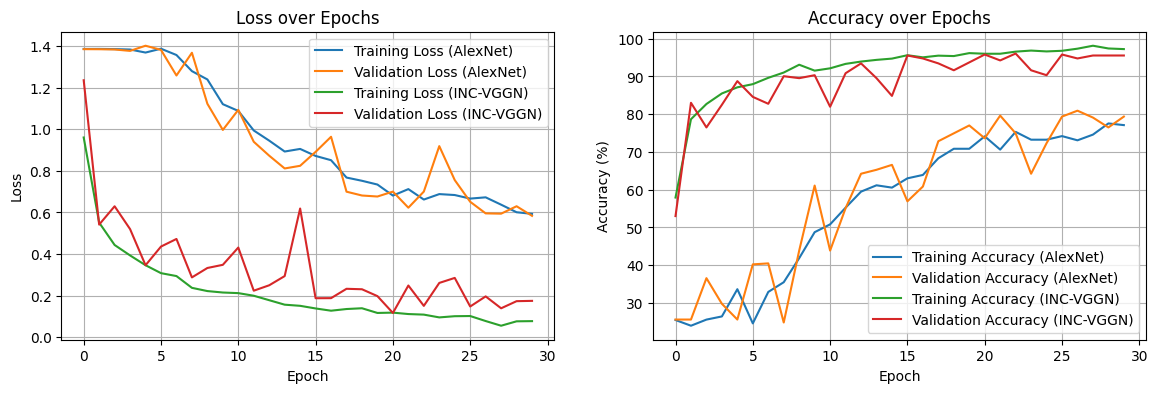

In [53]:
# Plot training history
plt.figure(figsize=(14, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_alexnet, label='Training Loss (AlexNet)')
plt.plot(val_loss_alexnet, label='Validation Loss (AlexNet)')
plt.plot(train_loss_incvggn, label='Training Loss (INC-VGGN)')
plt.plot(val_loss_incvggn, label='Validation Loss (INC-VGGN)')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_alexnet, label='Training Accuracy (AlexNet)')
plt.plot(val_acc_alexnet, label='Validation Accuracy (AlexNet)')
plt.plot(train_acc_incvggn, label='Training Accuracy (INC-VGGN)')
plt.plot(val_acc_incvggn, label='Validation Accuracy (INC-VGGN)')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

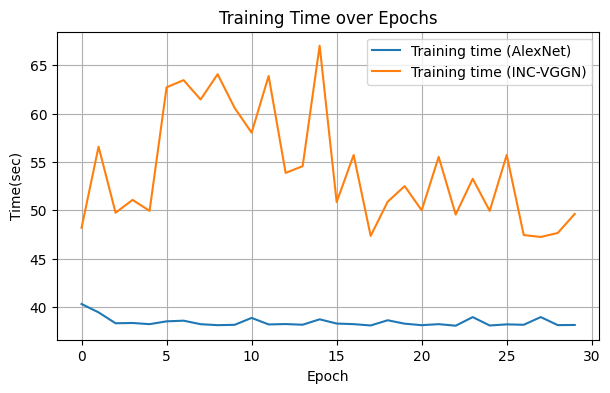

In [52]:
plt.figure(figsize=(7, 4))

plt.plot(train_time_alexnet, label='Training time (AlexNet)')
plt.plot(train_time_incvggn, label='Training time (INC-VGGN)')
plt.title('Training Time over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Time(sec)')
plt.legend()
plt.grid(True)

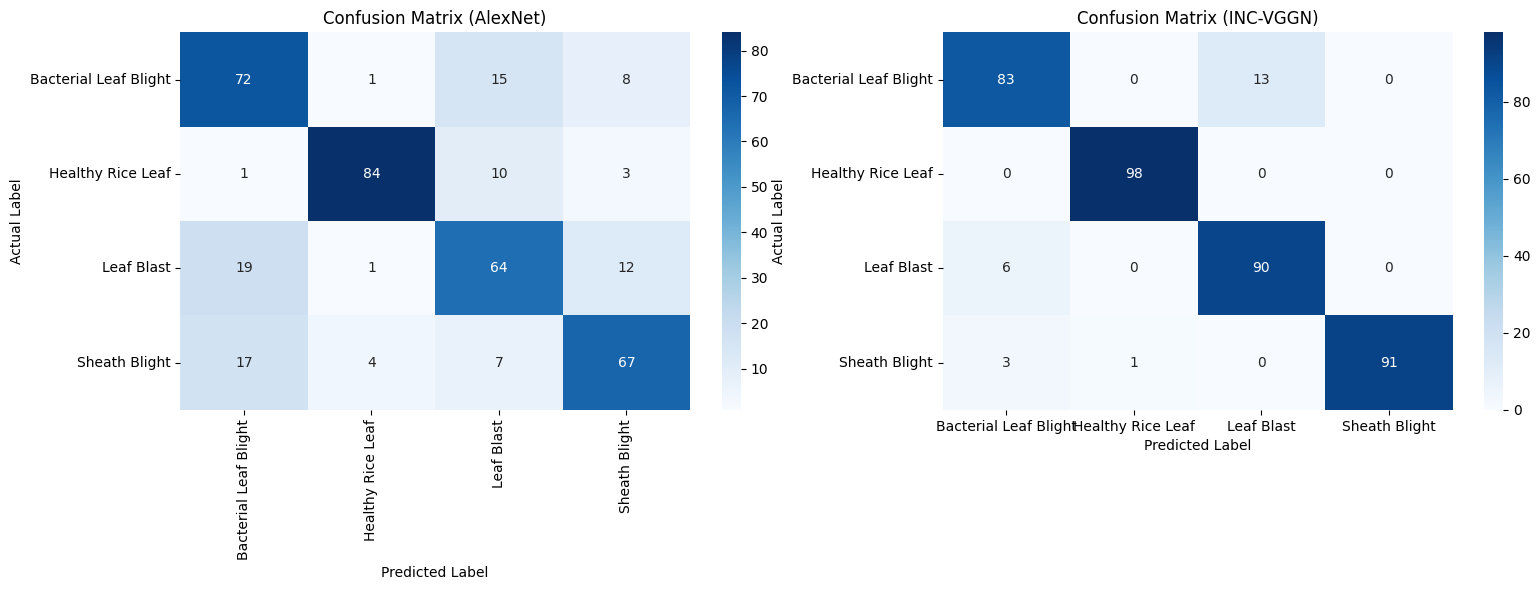

In [56]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_alexnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (AlexNet)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()

plt.subplot(1, 2, 2)
sns.heatmap(cm_incvggn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (INC-VGGN)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

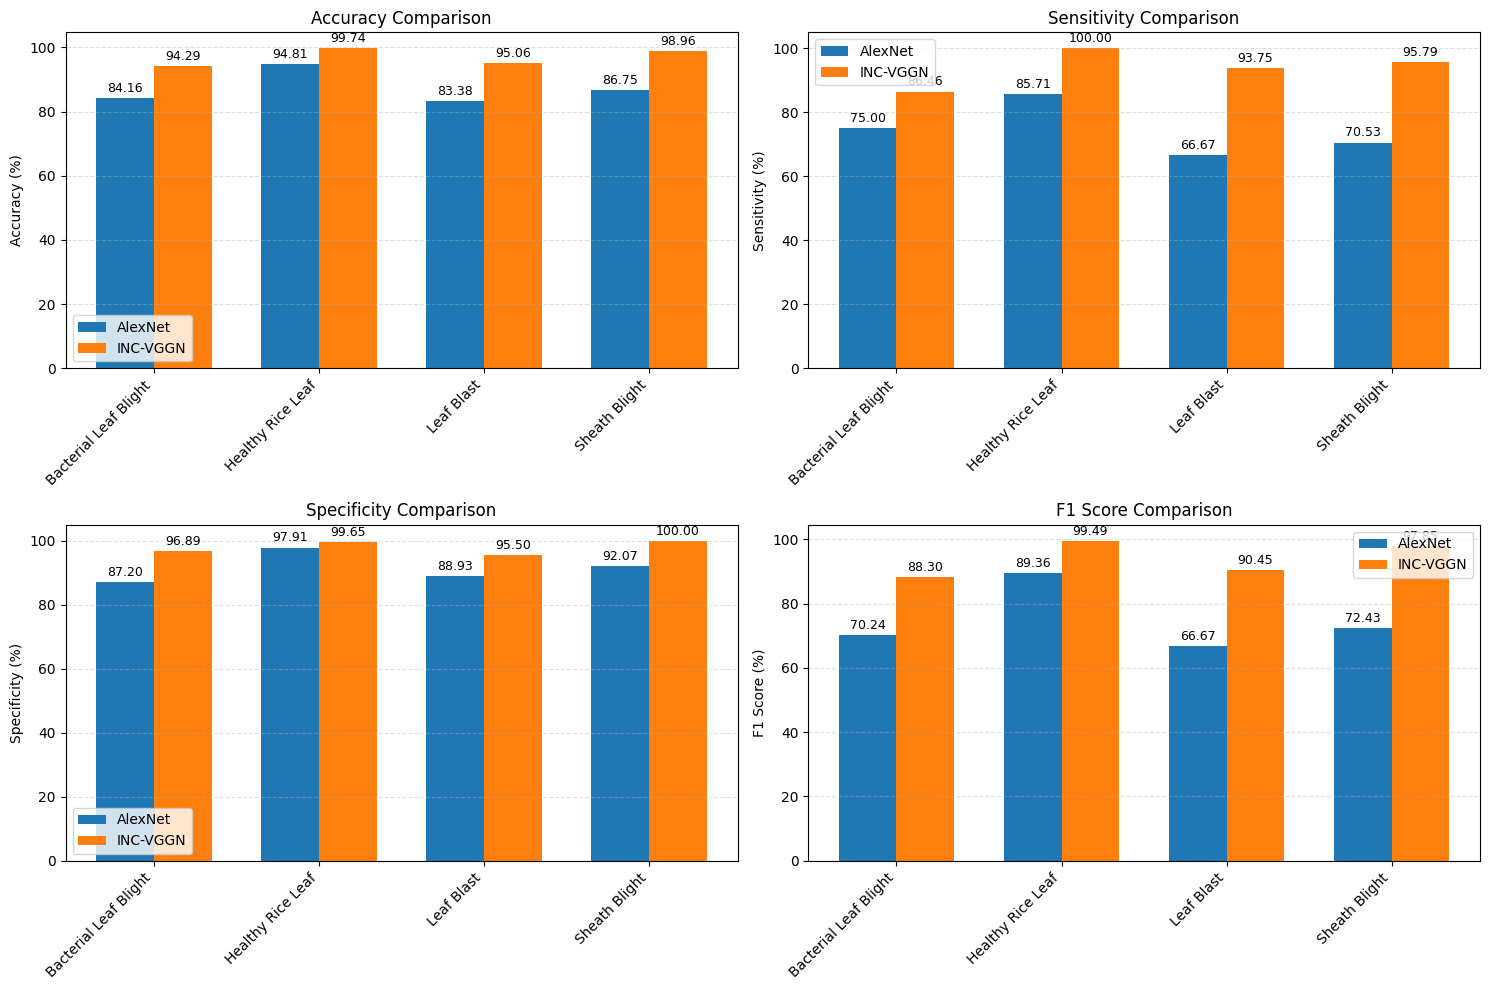

In [72]:
# Convert metric dictionaries to DataFrames
alexnet_df = pd.DataFrame(metrics_alexnet)
incvggn_df = pd.DataFrame(metrics_incvggn)

# Extract average rows
avg_alexnet = alexnet_df[alexnet_df['Class'] == 'Average'].iloc[0]
avg_incvggn = incvggn_df[incvggn_df['Class'] == 'Average'].iloc[0]

# Build summary table
metric_list = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']

summary_data = {
    'Metric': metric_list,
    'AlexNet': [avg_alexnet[m] for m in metric_list],
    'INC-VGGN': [avg_incvggn[m] for m in metric_list],
    'Improvement': [avg_incvggn[m] - avg_alexnet[m] for m in metric_list]
}

summary_df = pd.DataFrame(summary_data)

# Comparison table similar to Table 4
table4_comparison = pd.DataFrame({
    'Class': alexnet_df['Class'],
    'Accuracy_AlexNet': alexnet_df['Accuracy'],
    'Accuracy_INC-VGGN': incvggn_df['Accuracy'],
    'Sensitivity_AlexNet': alexnet_df['Sensitivity'],
    'Sensitivity_INC-VGGN': incvggn_df['Sensitivity'],
    'Specificity_AlexNet': alexnet_df['Specificity'],
    'Specificity_INC-VGGN': incvggn_df['Specificity']
})

# -------- Plot Section with Value Labels --------

def add_value_labels(bars):
    """Add numeric labels on bars."""
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.figure(figsize=(15, 10))

# Index excluding the "Average" row
x = np.arange(len(alexnet_df) - 1)
width = 0.35

# ----- 1. Accuracy -----
plt.subplot(2, 2, 1)
bars1 = plt.bar(x - width/2, alexnet_df.iloc[:-1]['Accuracy'], width, label='AlexNet')
bars2 = plt.bar(x + width/2, incvggn_df.iloc[:-1]['Accuracy'], width, label='INC-VGGN')
plt.title("Accuracy Comparison")
plt.xticks(x, alexnet_df.iloc[:-1]['Class'], rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
add_value_labels(bars1)
add_value_labels(bars2)
plt.legend()

# ----- 2. Sensitivity -----
plt.subplot(2, 2, 2)
bars1 = plt.bar(x - width/2, alexnet_df.iloc[:-1]['Sensitivity'], width, label='AlexNet')
bars2 = plt.bar(x + width/2, incvggn_df.iloc[:-1]['Sensitivity'], width, label='INC-VGGN')
plt.title("Sensitivity Comparison")
plt.xticks(x, alexnet_df.iloc[:-1]['Class'], rotation=45, ha='right')
plt.ylabel("Sensitivity (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
add_value_labels(bars1)
add_value_labels(bars2)
plt.legend()

# ----- 3. Specificity -----
plt.subplot(2, 2, 3)
bars1 = plt.bar(x - width/2, alexnet_df.iloc[:-1]['Specificity'], width, label='AlexNet')
bars2 = plt.bar(x + width/2, incvggn_df.iloc[:-1]['Specificity'], width, label='INC-VGGN')
plt.title("Specificity Comparison")
plt.xticks(x, alexnet_df.iloc[:-1]['Class'], rotation=45, ha='right')
plt.ylabel("Specificity (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
add_value_labels(bars1)
add_value_labels(bars2)
plt.legend()

# ----- 4. F1 Score -----
plt.subplot(2, 2, 4)
bars1 = plt.bar(x - width/2, alexnet_df.iloc[:-1]['F1 Score'], width, label='AlexNet')
bars2 = plt.bar(x + width/2, incvggn_df.iloc[:-1]['F1 Score'], width, label='INC-VGGN')
plt.title("F1 Score Comparison")
plt.xticks(x, alexnet_df.iloc[:-1]['Class'], rotation=45, ha='right')
plt.ylabel("F1 Score (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
add_value_labels(bars1)
add_value_labels(bars2)
plt.legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

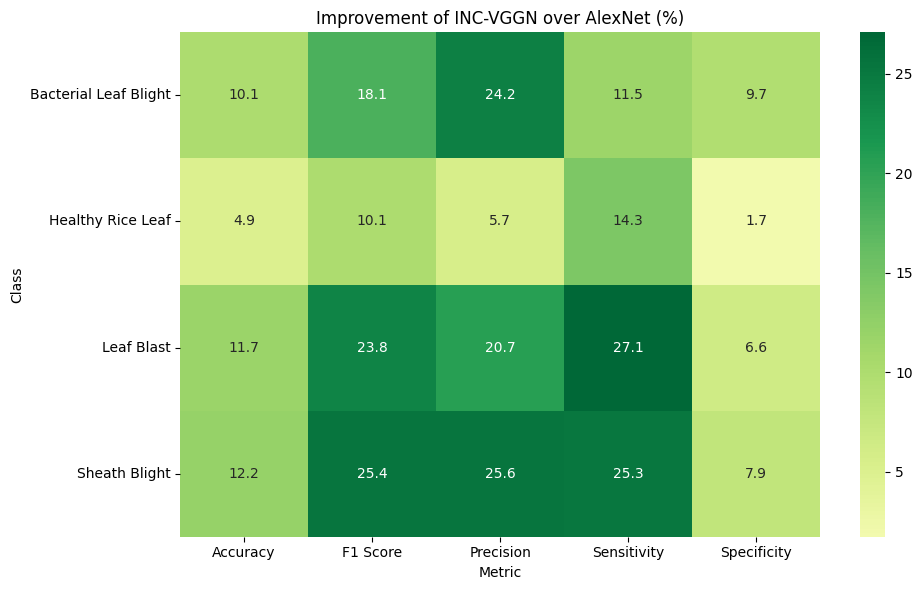

In [64]:
alexnet_df = pd.DataFrame(metrics_alexnet)
incvggn_df = pd.DataFrame(metrics_incvggn)

# Create a comparison table
comparison_data = []
for i in range(len(alexnet_df)):
    class_name = alexnet_df.iloc[i]['Class']
    for metric in ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score']:
        alexnet_val = alexnet_df.iloc[i][metric]
        incvggn_val = incvggn_df.iloc[i][metric]
        improvement = incvggn_val - alexnet_val
        comparison_data.append({
            'Class': class_name,
            'Metric': metric,
            'AlexNet': alexnet_val,
            'INC-VGGN': incvggn_val,
            'Improvement': improvement
        })

comparison_df = pd.DataFrame(comparison_data)

# Create a heatmap of improvements
improvement_matrix = comparison_df[comparison_df['Class'] != 'Average'].pivot(
    index='Class', columns='Metric', values='Improvement'
)

plt.figure(figsize=(10, 6))
sns.heatmap(improvement_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.1f')
plt.title('Improvement of INC-VGGN over AlexNet (%)')
plt.tight_layout()
plt.savefig('improvement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

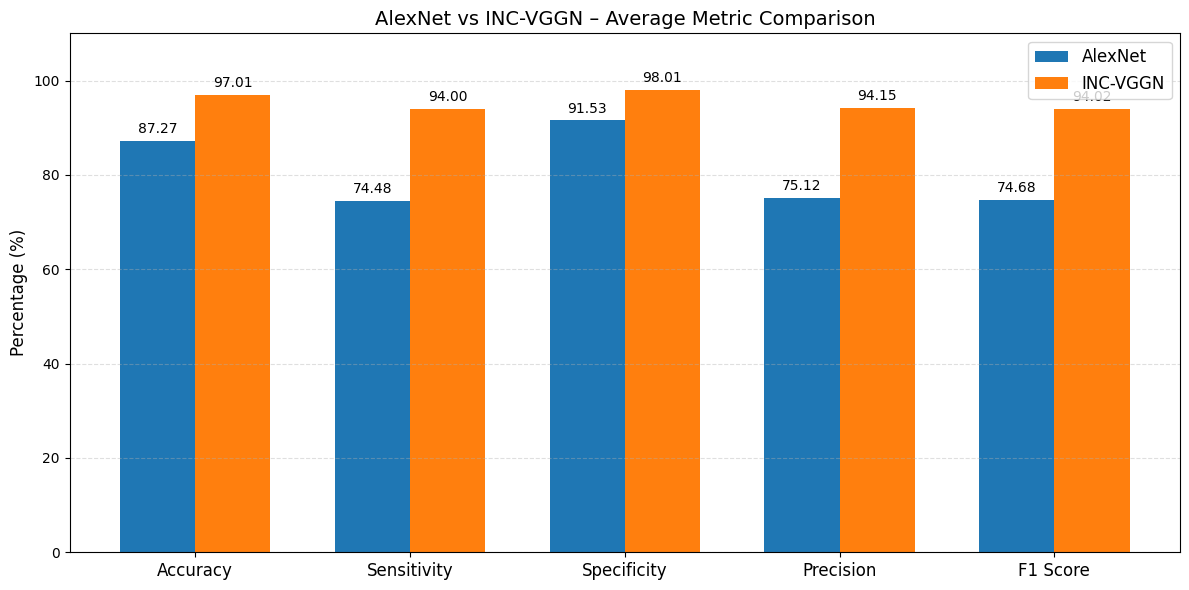

In [71]:
alexnet_df = pd.DataFrame(metrics_alexnet)
incvggn_df = pd.DataFrame(metrics_incvggn)

# Extract average rows
avg_alexnet = alexnet_df[alexnet_df['Class'] == 'Average'].iloc[0]
avg_incvggn = incvggn_df[incvggn_df['Class'] == 'Average'].iloc[0]

# Metrics to compare
metric_list = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1 Score"]

alex_values = [avg_alexnet[m] for m in metric_list]
vgg_values  = [avg_incvggn[m] for m in metric_list]

# ---- Improved Grouped Bar Plot ----
x = np.arange(len(metric_list))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2, alex_values, width, label="AlexNet")
bars2 = plt.bar(x + width/2, vgg_values,  width, label="INC-VGGN")

plt.xticks(x, metric_list, fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("AlexNet vs INC-VGGN – Average Metric Comparison", fontsize=14)

plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(fontsize=12)

# ---- Add numeric labels to bars ----
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.savefig("avg_metric_comparison_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

####